In [ ]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29 peft trl triton
    !pip install --no-deps cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [ ]:
import pandas as pd
import re
import random
from string import punctuation
import numpy as np

In [ ]:
url = 'https://docs.google.com/spreadsheets/d/1eLljmEHLfI01dqB8Li3bqPDP86wJCm9L/edit?usp=sharing&ouid=117999606608884179014&rtpof=true&sd=true'
file_id = url.split('/')[-2]
read_url='https://drive.google.com/uc?id=' + file_id

data_set = pd.read_excel(read_url, index_col=False)

condition = [
    data_set["rotulo_humano"] == "sem_sintoma", # 0
    data_set["rotulo_humano"] == "sintoma" # 1
]

values = [0, 1]

data_set["classification"] = np.select(condition, values)

data_set

,Texto,rotulo_humano,rotulo_vader,interpretacao_rotulo_vader,vader_metricas,classification
0,"Primeiro dia no trabalho novo, ansiedade lá em...",sintoma,negativo,sintoma,"{'neg': 0.338, 'neu': 0.662, 'pos': 0.0, 'comp...",1
1,"Por algum motivo, mesmo sendo 102% virgem eu e...",sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
2,Só queria me entupir de doce pra ver se essa a...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
3,odeio ter pensamentos automaticos contaminados...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
4,eu sinto que nos braços dela tem a cura da min...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
...,...,...,...,...,...,...
95,"Pow kkkkkk nem querendo defender, mas não dá p...",sem_sintoma,negativo,sintoma,"{'neg': 0.06, 'neu': 0.902, 'pos': 0.038, 'com...",0
96,Horrível ter que dormir e tirar as roupas do v...,sem_sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0
97,ai que bom que é normal então tava com medo de...,sem_sintoma,negativo,sintoma,"{'neg': 0.177, 'neu': 0.823, 'pos': 0.0, 'comp...",0
98,Garfield é ALFA mesmo sendo gordo pois ele tem...,sem_sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0


In [ ]:
from unsloth import FastLanguageModel
import torch
from transformers import TextStreamer
from unsloth.chat_templates import get_chat_template

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


    PyTorch 2.5.1+cu121 with CUDA 1201 (you have 2.8.0+cu126)
    Python  3.12.8 (you have 3.12.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


Switching to PyTorch attention since your Xformers is broken.

Unsloth: Xformers was not installed correctly.
Please install xformers separately first.
Then confirm if it's correctly installed by running:
python -m xformers.info

Longer error message:
xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.5.1+cu121 with CUDA 1201 (you have 2.8.0+cu126)
    Python  3.12.8 (you have 3.12.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length = 8192,
    load_in_4bit = True,
)

==((====))==  Unsloth 2025.10.11: Fast Llama patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

In [ ]:
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
    mapping = {"role" : "from", "content" : "value", "user" : "human", "assistant" : "gpt"}, # ShareGPT style
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128004)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm):

In [ ]:
def get_prompt(sentence):
  return f"""
    Você é um modelo de IA treinado para classificar frases quanto à ansiedade.

    Regras:
    - Se a frase indicar ansiedade ou depressão, retorne exatamente "1".
    - Se a frase não indicar ansiedade ou depressão, retorne exatamente "0".
    - Não adicione explicações.

    Frase: "{sentence}"
    """

In [ ]:
from tqdm import tqdm
import torch

answers_llm = {
    "text": data_set["Texto"].tolist(),
    "target": data_set["classification"].tolist(),
    "predicted": []
}

sentences = answers_llm["text"]

FastLanguageModel.for_inference(model)
device = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(device) # This line caused the error and is not needed for 8-bit models

batch_size = 16
for i in tqdm(range(0, len(sentences), batch_size)):
    batch = sentences[i:i + batch_size]

    prompts = [get_prompt(sentence) for sentence in batch]
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(device)
    input_token_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=128)

    decoded_batch = tokenizer.batch_decode(outputs[:, input_token_len:], skip_special_tokens=True)

    decoded_batch = [t.strip() for t in decoded_batch]
    answers_llm["predicted"].extend(decoded_batch)

100%|██████████| 7/7 [03:53<00:00, 33.40s/it]


In [ ]:

# from google.colab import files

df = pd.DataFrame(answers_llm)
df.to_csv('/content/drive/MyDrive/Notebooks/Others/Outputs/respostas_llama3.csv', index=False)

# files.download('respostas_llama3.xlsx')


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

y_true = answers_llm["target"]
y_pred = answers_llm["predicted"]

y_true = [int(x) for x in y_true]
y_pred = [int(x.strip()) if x.strip() in ['0', '1'] else 0 for x in y_pred]

acc = accuracy_score(y_true, y_pred)
print(f"Acurácia: {acc:.4f}")

print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=["Sem ansiedade (0)", "Com ansiedade (1)"]))

Acurácia: 0.4900

Relatório de Classificação:
                   precision    recall  f1-score   support

Sem ansiedade (0)       0.49      0.72      0.59        50
Com ansiedade (1)       0.48      0.26      0.34        50

         accuracy                           0.49       100
        macro avg       0.49      0.49      0.46       100
     weighted avg       0.49      0.49      0.46       100



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_preds, y_true, labels=None):
  cm = confusion_matrix(y_true, y_preds, normalize="true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

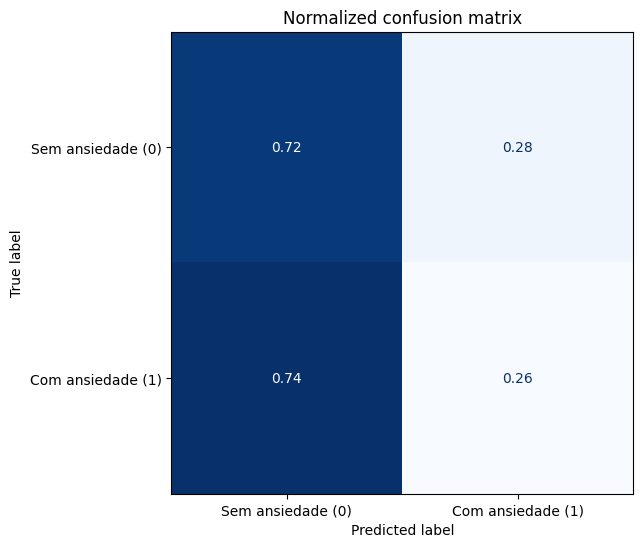

In [ ]:
plot_confusion_matrix(y_pred, y_true, labels=["Sem ansiedade (0)", "Com ansiedade (1)"])